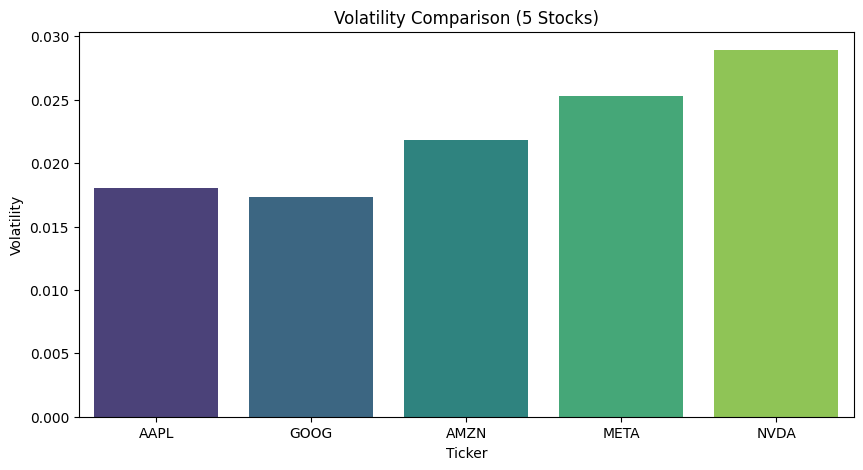

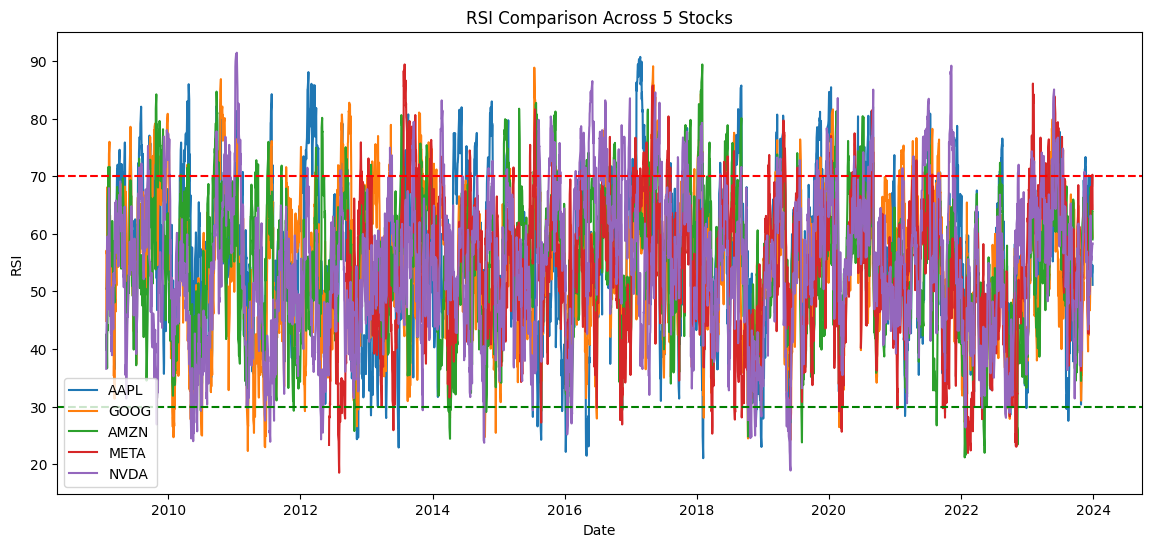

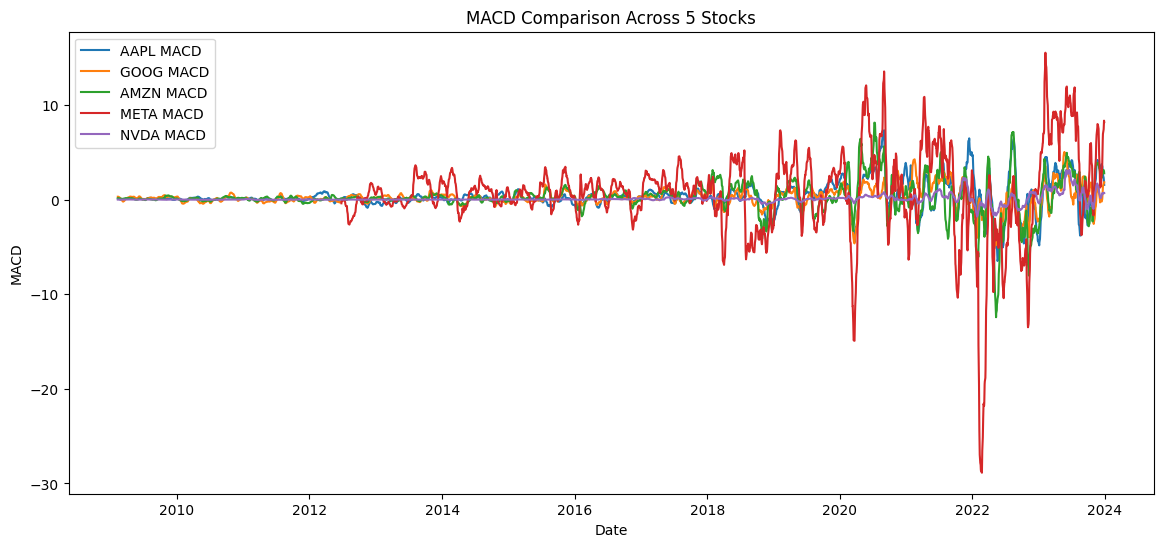

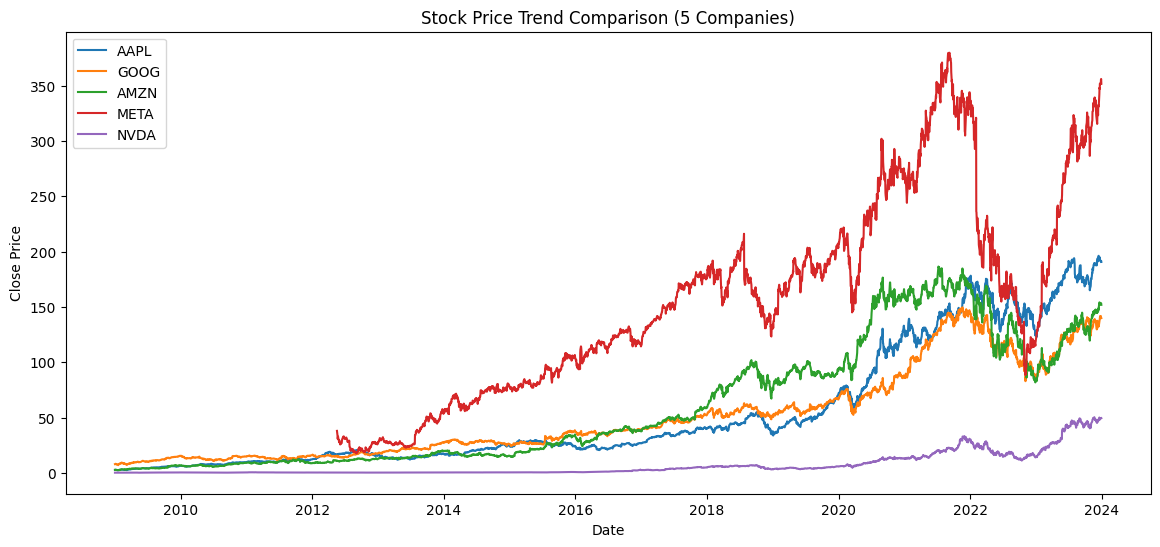

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta
import os

# -----------------------------
# CONFIG
# -----------------------------
tickers = ["AAPL", "GOOG", "AMZN", "META", "NVDA"]
path_template = "../data/raw/{}.csv"

all_data = []
volatility_results = []

# -----------------------------
# LOAD + PROCESS DATA
# -----------------------------
for ticker in tickers:

    path = path_template.format(ticker)

    if not os.path.exists(path):
        print(f"Missing file: {path}")
        continue

    df = pd.read_csv(path)
    df["Ticker"] = ticker

    # Date handling
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.sort_values("Date")

    # Numeric conversion
    cols = ["Open", "High", "Low", "Close", "Volume"]
    df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")

    df = df.dropna()

    # -----------------------------
    # TECHNICAL INDICATORS
    # -----------------------------

    # Moving Averages
    df["SMA_20"] = ta.trend.sma_indicator(df["Close"], window=20)
    df["SMA_50"] = ta.trend.sma_indicator(df["Close"], window=50)
    df["EMA_20"] = ta.trend.ema_indicator(df["Close"], window=20)

    # RSI
    df["RSI"] = ta.momentum.rsi(df["Close"], window=14)

    # MACD
    macd = ta.trend.MACD(df["Close"])
    df["MACD"] = macd.macd()
    df["MACD_signal"] = macd.macd_signal()
    df["MACD_diff"] = macd.macd_diff()

    # Returns + Volatility
    df["returns"] = df["Close"].pct_change()
    df["volatility"] = df["returns"].rolling(7).std()

    # Store volatility summary
    volatility_results.append({
        "Ticker": ticker,
        "Volatility": df["returns"].std()
    })

    all_data.append(df)

# -----------------------------
# FINAL DATA
# -----------------------------
final_df = pd.concat(all_data, ignore_index=True)
vol_df = pd.DataFrame(volatility_results)

# -----------------------------
# VOLATILITY PLOT
# -----------------------------
plt.figure(figsize=(10,5))

sns.barplot(
    data=vol_df,
    x="Ticker",
    y="Volatility",
    hue="Ticker",
    palette="viridis",
    legend=False
)

plt.title("Volatility Comparison (5 Stocks)")
plt.show()

# -----------------------------
# RSI (ALL STOCKS IN ONE GRAPH)
# -----------------------------
plt.figure(figsize=(14,6))

for ticker in tickers:
    temp = final_df[final_df["Ticker"] == ticker]
    plt.plot(temp["Date"], temp["RSI"], label=ticker)

plt.axhline(70, color="red", linestyle="--")
plt.axhline(30, color="green", linestyle="--")

plt.title("RSI Comparison Across 5 Stocks")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.show()

# -----------------------------
# MACD (ALL STOCKS IN ONE GRAPH)
# -----------------------------
plt.figure(figsize=(14,6))

for ticker in tickers:
    temp = final_df[final_df["Ticker"] == ticker]
    plt.plot(temp["Date"], temp["MACD"], label=f"{ticker} MACD")

plt.title("MACD Comparison Across 5 Stocks")
plt.xlabel("Date")
plt.ylabel("MACD")
plt.legend()
plt.show()

#STOCK PRICE TRAIND
plt.figure(figsize=(14,6))

for ticker in tickers:
    temp = final_df[final_df["Ticker"] == ticker]
    plt.plot(temp["Date"], temp["Close"], label=ticker)

plt.title("Stock Price Trend Comparison (5 Companies)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()